In [ ]:
# BioMedCLIP MRNet Zero-Shot Optimized Code

!pip install open_clip_torch > /dev/null

import os
import numpy as np
import pandas as pd
import torch
import cv2
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import open_clip
from PIL import Image
from tqdm import tqdm

# 1. Setup & Model Loading
from google.colab import drive
drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths
base_path = "/content/drive/MyDrive/MrNet-v1/MRNet-v1.0"
axial_dir = base_path + "/merged_data/axial"
coronal_dir = base_path + "/merged_data/coronal"
sagittal_dir = base_path + "/merged_data/sagittal"
val_df = pd.read_csv(base_path + "/val_split.csv")

# Load BioMedCLIP
print("Loading BioMedCLIP...")
model_name = 'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
model, _, preprocess = open_clip.create_model_and_transforms(model_name)
model = model.to(device)
model.eval()
tokenizer = open_clip.get_tokenizer(model_name)
print("BioMedCLIP Loaded successfully!")





Mounted at /content/drive
Using device: cuda
Loading BioMedCLIP...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

BioMedCLIP Loaded successfully!


In [ ]:
# Step 2: Clinical Prompt Ensembling Logic

def get_refined_text_features(plane_name):
    """
    Uses domain-specific medical descriptions to help BioMedCLIP
    understand ACL tears better in a zero-shot setting.
    """
    # Healthy Prompts: focusing on continuity and low signal
    prompts_healthy = [
        f"A {plane_name} view MRI of a knee with a normal, intact anterior cruciate ligament.",
        f"Knee MRI showing continuous low signal intensity of the ACL in {plane_name} plane.",
        f"A healthy knee MRI in {plane_name} view where the ACL is well-defined and preserved."
    ]

    # Tear Prompts: focusing on discontinuity and edema
    prompts_tear = [
        f"A {plane_name} plane MRI slice showing a complete ACL tear and fiber disruption.",
        f"An anterior cruciate ligament rupture with abnormal high signal intensity in {plane_name} view MRI.",
        f"Knee MRI slice showing significant edema and discontinuity in the ACL region."
    ]

    with torch.no_grad():
        tok_h = tokenizer(prompts_healthy).to(device)
        feat_h = model.encode_text(tok_h).mean(dim=0, keepdim=True)

        tok_t = tokenizer(prompts_tear).to(device)
        feat_t = model.encode_text(tok_t).mean(dim=0, keepdim=True)

        text_features = torch.cat([feat_h, feat_t], dim=0)
        text_features /= text_features.norm(dim=-1, keepdim=True)

    return text_features



In [ ]:
# Step 3: Dataset with CLAHE Normalization


def fix_slices(volume, target_slices=20):
    slices = volume.shape[0]
    if slices == target_slices: return volume
    if slices > target_slices:
        start = (slices - target_slices) // 2
        return volume[start:start + target_slices]
    else:
        pad = target_slices - slices
        return np.pad(volume, ((pad//2, pad - pad//2), (0, 0), (0, 0)), mode="constant")

class BioMedCLIP_Dataset(Dataset):
    def __init__(self, df, plane_dir):
        self.df = df
        self.plane_dir = plane_dir
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        patient_id = str(self.df.iloc[idx]["id"]).zfill(4)
        label = self.df.iloc[idx]["label"]
        vol = np.load(os.path.join(self.plane_dir, patient_id + ".npy"))
        vol = fix_slices(vol)

        processed_slices = []
        for i in range(vol.shape[0]):
            # 1. Min-Max Scaling
            img = vol[i]
            img = (img - img.min()) / (img.max() - img.min() + 1e-6)
            img = (img * 255).astype(np.uint8)

            # 2. CLAHE for contrast enhancement (crucial for ligaments)
            img = self.clahe.apply(img)
            img = cv2.resize(img, (224, 224))

            # 3. Stack to RGB and Preprocess
            img_rgb = np.stack((img,)*3, axis=-1)
            img_tensor = preprocess(Image.fromarray(img_rgb))
            processed_slices.append(img_tensor)

        return torch.stack(processed_slices), torch.tensor(label, dtype=torch.float32)

In [ ]:
# Step 4: Zero-Shot Inference Logic

def run_inference(plane_name, plane_dir):
    print(f"\nEvaluating {plane_name.upper()} Plane...")
    text_features = get_refined_text_features(plane_name)
    dataset = BioMedCLIP_Dataset(val_df, plane_dir)
    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    all_probs = []
    y_true = []

    with torch.no_grad():
        for imgs, lbl in tqdm(loader):
            imgs = imgs.squeeze(0).to(device) # [20, 3, 224, 224]

            image_features = model.encode_image(imgs)
            image_features /= image_features.norm(dim=-1, keepdim=True)

            logits = (model.logit_scale.exp() * image_features @ text_features.t()).softmax(dim=-1)
            prob_tear_per_slice = logits[:, 1]

            # Weighted Top-K Aggregation for stability
            topk_vals, _ = torch.topk(prob_tear_per_slice, k=3)
            # Weighted mean gives higher importance to the most suspicious slice
            final_prob = (topk_vals[0] * 0.5 + topk_vals[1] * 0.3 + topk_vals[2] * 0.2).item()

            all_probs.append(final_prob)
            y_true.append(lbl.item())

    return np.array(all_probs), np.array(y_true)


Evaluating AXIAL Plane...


100%|██████████| 125/125 [01:34<00:00,  1.33it/s]



Evaluating CORONAL Plane...


100%|██████████| 125/125 [01:31<00:00,  1.37it/s]



Evaluating SAGITTAL Plane...


100%|██████████| 125/125 [01:37<00:00,  1.28it/s]



FINAL ZERO-SHOT ENSEMBLE RESULTS
Optimal Threshold: 0.7805
Ensemble AUC:      0.5602
Ensemble Accuracy: 72.00%


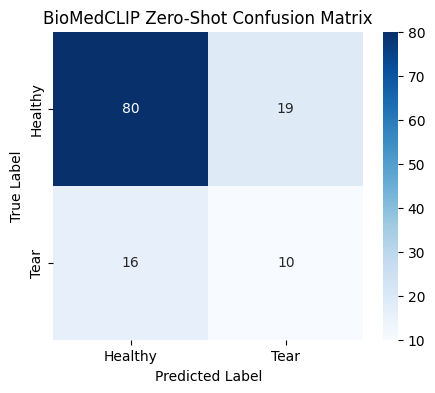

In [ ]:
# Step 5: Execute Multi-Plane Fusion

axial_p, y_true = run_inference("axial", axial_dir)
coronal_p, _ = run_inference("coronal", coronal_dir)
sagittal_p, _ = run_inference("sagittal", sagittal_dir)

# FINAL FUSION: Simple average of 3 planes
# Note: Sagittal often carries more weight, but 1:1:1 is standard for zero-shot
ensemble_probs = (axial_p + coronal_p + sagittal_p) / 3.0

# Find Optimal Threshold using Validation Set
fpr, tpr, thresholds = roc_curve(y_true, ensemble_probs)
opt_idx = np.argmax(tpr - fpr)
opt_thresh = thresholds[opt_idx]

# Results
auc = roc_auc_score(y_true, ensemble_probs)
preds = (ensemble_probs >= opt_thresh).astype(int)
acc = accuracy_score(y_true, preds)

print("\n" + "="*40)
print("FINAL ZERO-SHOT ENSEMBLE RESULTS")
print("="*40)
print(f"Optimal Threshold: {opt_thresh:.4f}")
print(f"Ensemble AUC:      {auc:.4f}")
print(f"Ensemble Accuracy: {acc*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_true, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Tear'], yticklabels=['Healthy', 'Tear'])
plt.title("BioMedCLIP Zero-Shot Confusion Matrix")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()